In [1]:
import pandas as pd
import numpy as np
data= pd.read_csv("data/diabetes1.csv")
print(data.shape)


(4500, 10)


In [2]:
print(data.head())
print(data.info())

   ID  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0   1            1       84             58             26      129  33.3   
1   2            4      160             71             23      265  30.2   
2   3            4      174             72             37      737  29.7   
3   4            5       94             73             33       78  34.1   
4   5            3       91             86             34       41  38.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.970   31        0  
1                     0.193   55        0  
2                     0.210   38        0  
3                     0.266   46        0  
4                     0.228   24        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        4500 non-null   int64  
 1   Pr

In [3]:
data= data.drop('ID', axis=1)
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       84             58             26      129  33.3   
1            4      160             71             23      265  30.2   
2            4      174             72             37      737  29.7   
3            5       94             73             33       78  34.1   
4            3       91             86             34       41  38.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.970   31        0  
1                     0.193   55        0  
2                     0.210   38        0  
3                     0.266   46        0  
4                     0.228   24        0  


In [4]:
# Print the shape of the datasets
print("Dataset 1 shape:", data.shape)
print(data.info())


Dataset 1 shape: (4500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               4500 non-null   int64  
 1   Glucose                   4500 non-null   int64  
 2   BloodPressure             4500 non-null   int64  
 3   SkinThickness             4500 non-null   int64  
 4   Insulin                   4500 non-null   int64  
 5   BMI                       4500 non-null   float64
 6   DiabetesPedigreeFunction  4500 non-null   float64
 7   Age                       4500 non-null   int64  
 8   Outcome                   4500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 316.5 KB
None


This is important because your large datasets don't use exactly the same column names as your current Pima dataset.

In [5]:
# Print the column names of the datasets
print("Dataset 1 columns:")
print(data.columns.tolist())

Dataset 1 columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [6]:
# Check missing values
print(data.isnull().sum())
# Check zero values in each column
print((data == 0).sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Pregnancies                  682
Glucose                        0
BloodPressure                  0
SkinThickness                  0
Insulin                        0
BMI                            0
DiabetesPedigreeFunction       0
Age                            0
Outcome                     2930
dtype: int64


In [7]:
# Remove duplicates values from the dataset
print("Before removing duplicates:", data.shape)
data = data.drop_duplicates()
print("After removing duplicates:", data.shape)

Before removing duplicates: (4500, 9)
After removing duplicates: (4500, 9)


In [8]:
# Replace zero values with NaN for specific columns
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[columns] = data[columns].replace(0, np.nan)
# Check missing values after replacement
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
# Fill misssing values with median of each column
for column in columns:
    data[column] = data[column].fillna(data[column].median())

print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
# Verify the changes by checking the first 5 rows of the dataset again
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       84             58             26      129  33.3   
1            4      160             71             23      265  30.2   
2            4      174             72             37      737  29.7   
3            5       94             73             33       78  34.1   
4            3       91             86             34       41  38.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.970   31        0  
1                     0.193   55        0  
2                     0.210   38        0  
3                     0.266   46        0  
4                     0.228   24        0  


Dataset
   ↓
Check missing values
   ↓
Find invalid zeros
   ↓
Replace zeros with NaN
   ↓
Fill NaN using median
   ↓
Clean dataset 

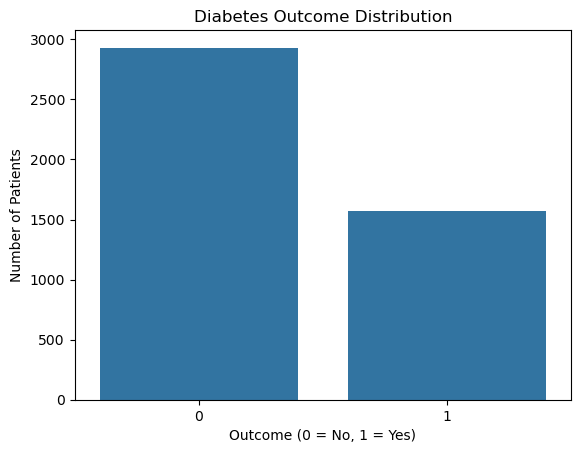

In [11]:
# Here we will visualize the distribution of the target variable 'Outcome' to understand the balance of classes in the dataset.
import matplotlib.pyplot as plt
import seaborn as sns

# Count of diabetes outcomes
sns.countplot(x='Outcome', data=data)

plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

In [12]:
# Now, let's visualize the correlation between different features in the dataset using a heatmap.
#plt.figure(figsize=(10, 7))
#sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
#plt.title('Feature Correlation')
#plt.show()

Load dataset
     ↓
Check missing values
     ↓
Check zero values
     ↓
Clean invalid values
     ↓
Create Outcome distribution graph
     ↓
Create correlation heatmap
     ↓
EDA 

In [13]:
# Separate features and target
X = data.drop('Outcome', axis=1)  # Take all columns except Outcome as input.
y = data['Outcome'] # Take Outcome column as target.
# Display the first 5 rows of features and target
print("Features:")
print(X.head())
# Display the first 5 rows of target
print("\nTarget:")
print(y.head())

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       84             58             26      129  33.3   
1            4      160             71             23      265  30.2   
2            4      174             72             37      737  29.7   
3            5       94             73             33       78  34.1   
4            3       91             86             34       41  38.3   

   DiabetesPedigreeFunction  Age  
0                     0.970   31  
1                     0.193   55  
2                     0.210   38  
3                     0.266   46  
4                     0.228   24  

Target:
0    0
1    0
2    0
3    0
4    0
Name: Outcome, dtype: int64


In [14]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape) # (614, 8)
print("Testing data:", X_test.shape)

Training data: (3600, 8)
Testing data: (900, 8)


# Here, we train first ML Model
0 → No recorded diabetes outcome
1 → Diabetes outcome

In [15]:
# Create a new notebook cell:
from sklearn.linear_model import LogisticRegression

In [16]:
# Create a Logistic Regression model with a maximum of 1000 iterations to ensure convergence.
model = LogisticRegression(max_iter=1000)

Let the model learn the relationship between the input features (X_train) and the known outcomes (y_train).

In [17]:
# Train the model using the training data
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


# Conceptually
X_train                         y_train
   │                               │
   │       Training               │
   └───────────┬───────────────────┘
               ↓
       Logistic Regression
               ↓
         Learned Model

Now, Make predictions:

In [18]:
# Make predictions on the testing set
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0
 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0
 1 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 0
 0 1 1 1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0
 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 1 0
 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 1 0
 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0
 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1
 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0
 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 1 1 0 0 1 0
 0 1 1 0 0 1 0 1 0 0 0 1 

We have:
X_test
   ↓
Trained Model
   ↓
Predicted Outcome
   ↓
y_pred

# Now Check Accuracy
Now we compare the model's predictions (y_pred) with the actual answers (y_test).

In [19]:
from sklearn.metrics import accuracy_score
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

Accuracy: 0.79
Accuracy in percentage: 79.0 %


# Classification report
Accuracy alone doesn't tell us everything. Now we'll check Precision, Recall, and F1-score.

In [20]:
from sklearn.metrics import classification_report
# Generate a classification report to evaluate the model's performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       589
           1       0.73      0.62      0.67       311

    accuracy                           0.79       900
   macro avg       0.77      0.75      0.76       900
weighted avg       0.79      0.79      0.79       900



# ML WorkFlow
Dataset
   ↓
Cleaning
   ↓
EDA
   ↓
X / y
   ↓
80/20 Train-Test Split
   ↓
Logistic Regression
   ↓
Predictions
   ↓
Accuracy
   ↓
Classification Report

# Confusion Matrix
exactly how many predictions were correct and incorrect.

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate a confusion matrix to visualize the performance of the model
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[519  70]
 [119 192]]


# Save the trained model

In [22]:
# joblib is a library for efficiently serializing and deserializing Python objects, which is particularly useful for saving machine learning models. In this case, we will use joblib to save the trained Logistic Regression model to a file so that it can be loaded and used later without needing to retrain it.
import joblib

In [23]:
# Save the trained model to a file using joblib
joblib.dump(model, 'model/diabetes_model.pkl')
print("Model saved successfully!")

Model saved successfully!


.pkl is a saved Python object containing our trained ML model